# Predicting Flood Probability  

## Introduction  
Floods are devastating natural disasters, but accurate predictions can help mitigate their impacts. This competition challenges participants to predict the probability of flooding in a region using environmental data.  

[Access the dataset here.](https://www.kaggle.com/competitions/playground-series-s4e5/data)  


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [35]:
train= pd.read_csv("train.csv")
test= pd.read_csv("test.csv")

In [36]:
train.head()

,id,MonsoonIntensity,TopographyDrainage,RiverManagement,Deforestation,Urbanization,ClimateChange,DamsQuality,Siltation,AgriculturalPractices,...,DrainageSystems,CoastalVulnerability,Landslides,Watersheds,DeterioratingInfrastructure,PopulationScore,WetlandLoss,InadequatePlanning,PoliticalFactors,FloodProbability
0,0,5,8,5,8,6,4,4,3,3,...,5,3,3,5,4,7,5,7,3,0.445
1,1,6,7,4,4,8,8,3,5,4,...,7,2,0,3,5,3,3,4,3,0.450
2,2,6,5,6,7,3,7,1,5,4,...,7,3,7,5,6,8,2,3,3,0.530
3,3,3,4,6,5,4,8,4,7,6,...,2,4,7,4,4,6,5,7,5,0.535
4,4,5,3,2,6,4,4,3,3,3,...,2,2,6,6,4,1,2,3,5,0.415


In [37]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1117957 entries, 0 to 1117956
Data columns (total 22 columns):
 #   Column                           Non-Null Count    Dtype  
---  ------                           --------------    -----  
 0   id                               1117957 non-null  int64  
 1   MonsoonIntensity                 1117957 non-null  int64  
 2   TopographyDrainage               1117957 non-null  int64  
 3   RiverManagement                  1117957 non-null  int64  
 4   Deforestation                    1117957 non-null  int64  
 5   Urbanization                     1117957 non-null  int64  
 6   ClimateChange                    1117957 non-null  int64  
 7   DamsQuality                      1117957 non-null  int64  
 8   Siltation                        1117957 non-null  int64  
 9   AgriculturalPractices            1117957 non-null  int64  
 10  Encroachments                    1117957 non-null  int64  
 11  IneffectiveDisasterPreparedness  1117957 non-null 

In [38]:
test.isnull().sum()

id                                 0
MonsoonIntensity                   0
TopographyDrainage                 0
RiverManagement                    0
Deforestation                      0
Urbanization                       0
ClimateChange                      0
DamsQuality                        0
Siltation                          0
AgriculturalPractices              0
Encroachments                      0
IneffectiveDisasterPreparedness    0
DrainageSystems                    0
CoastalVulnerability               0
Landslides                         0
Watersheds                         0
DeterioratingInfrastructure        0
PopulationScore                    0
WetlandLoss                        0
InadequatePlanning                 0
PoliticalFactors                   0
dtype: int64

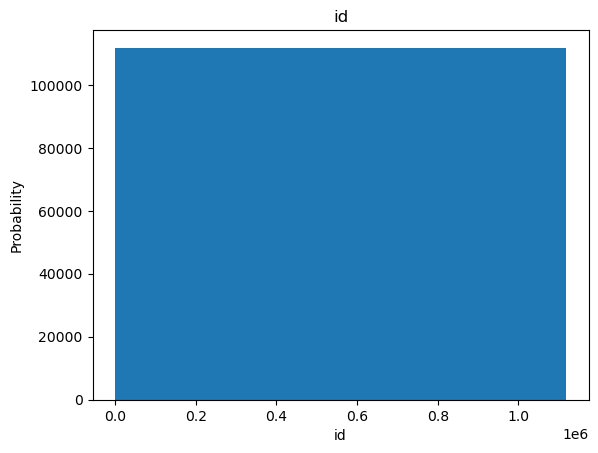

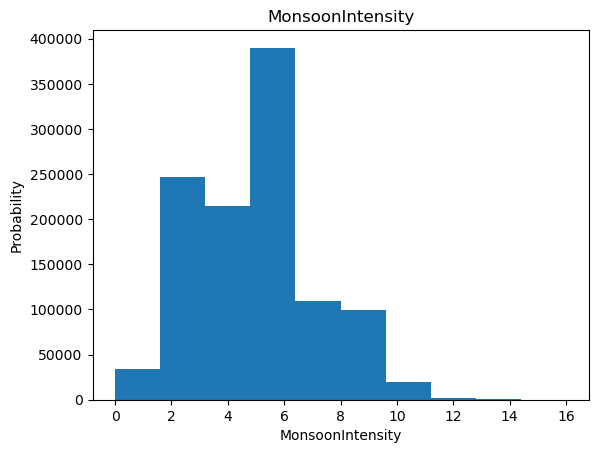

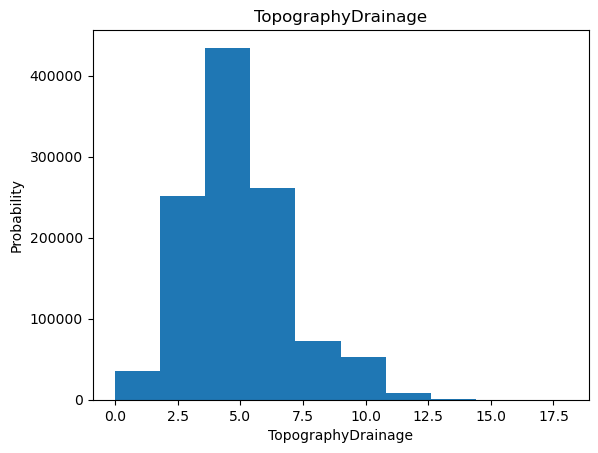

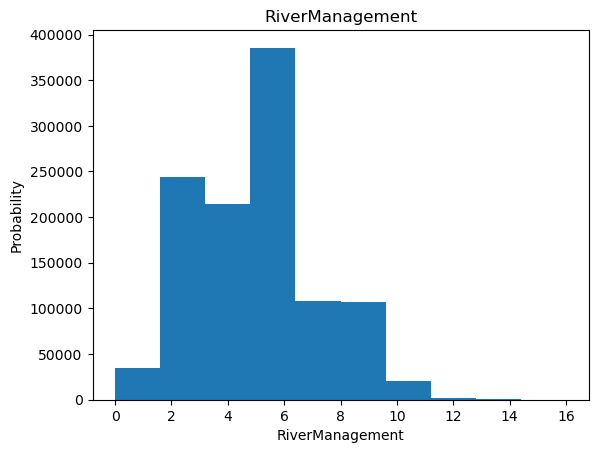

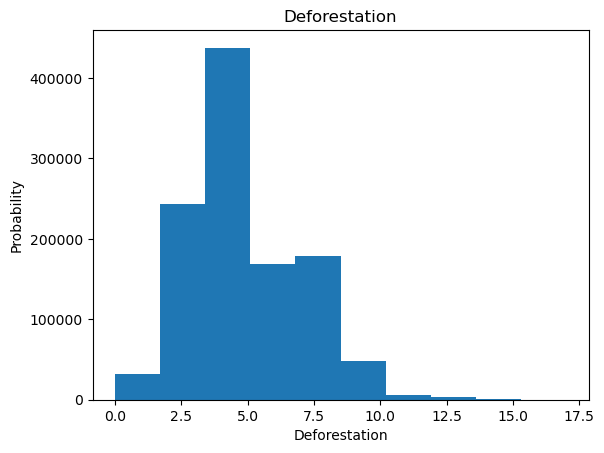

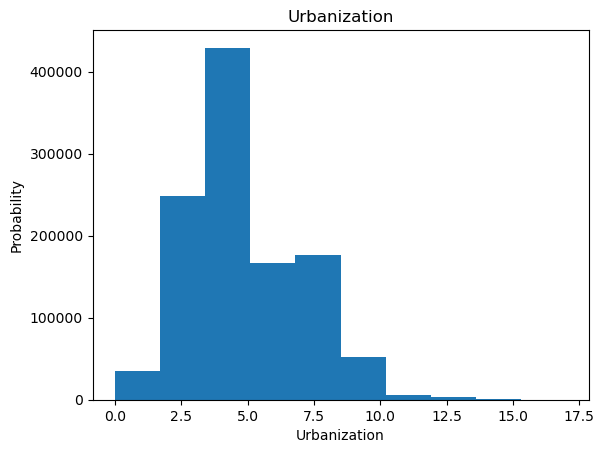

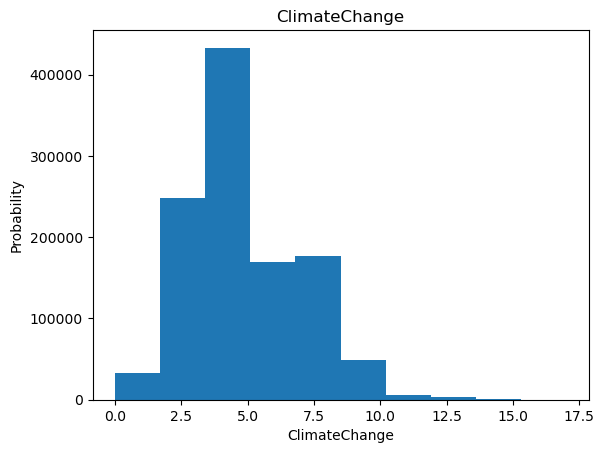

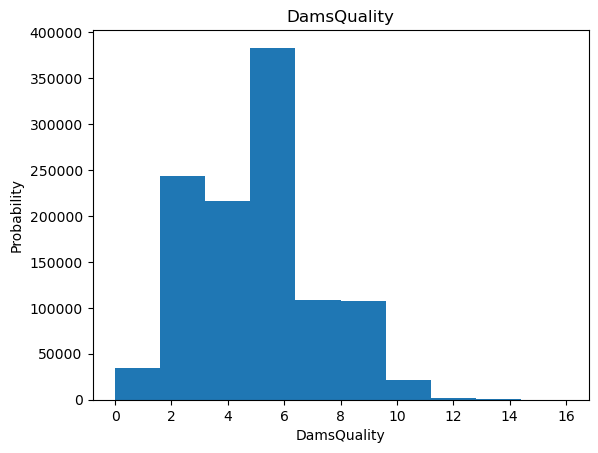

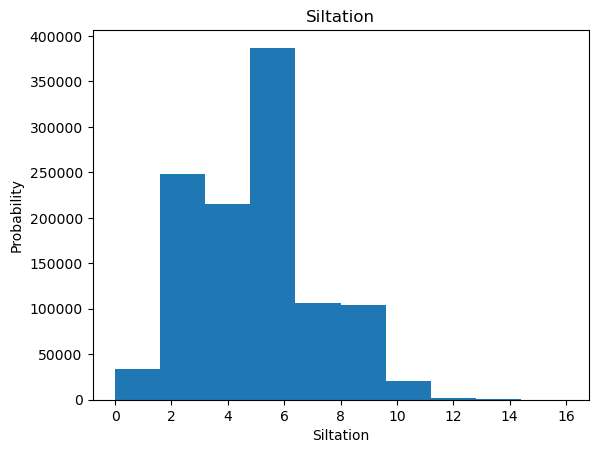

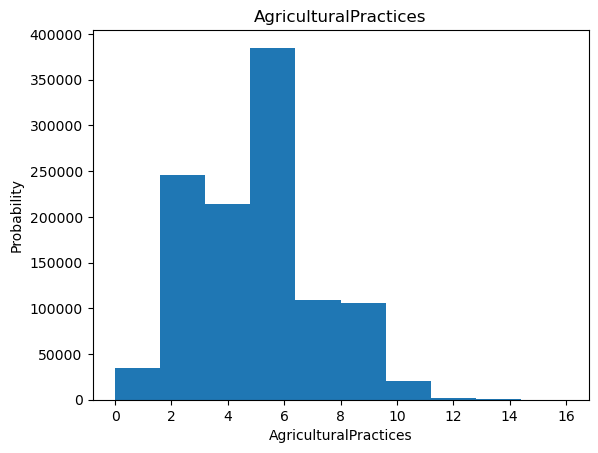

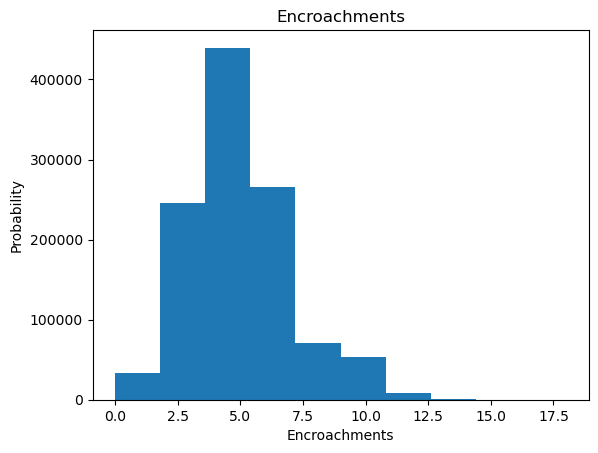

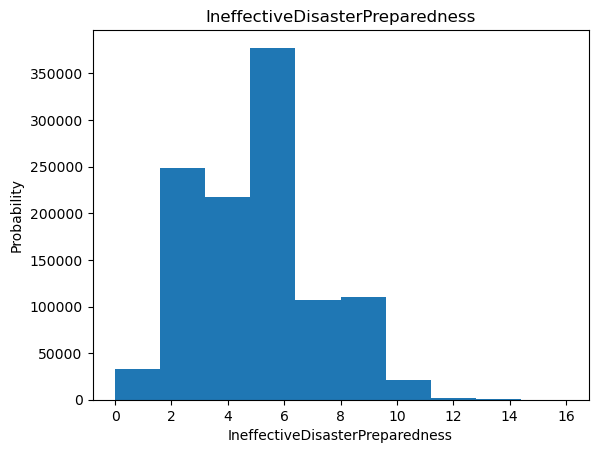

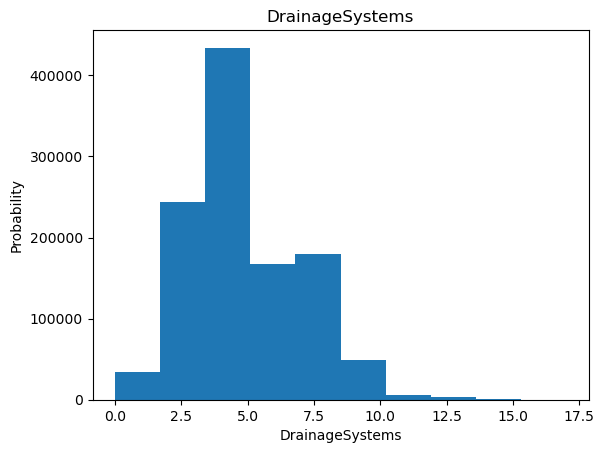

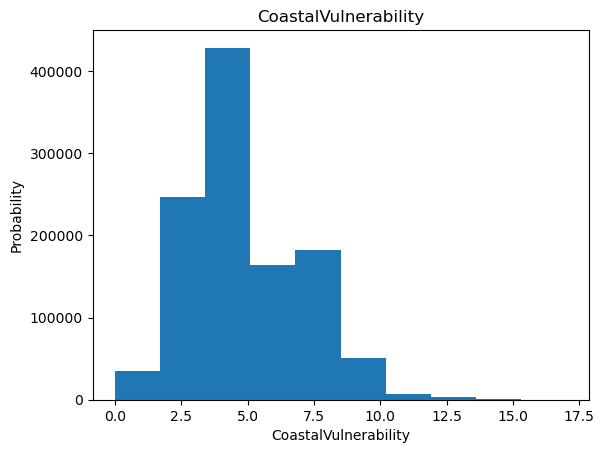

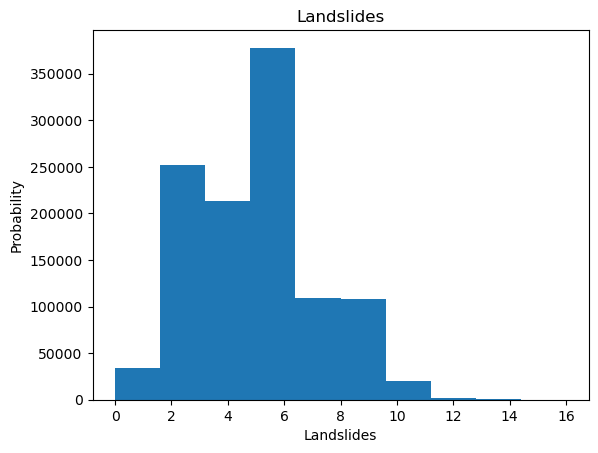

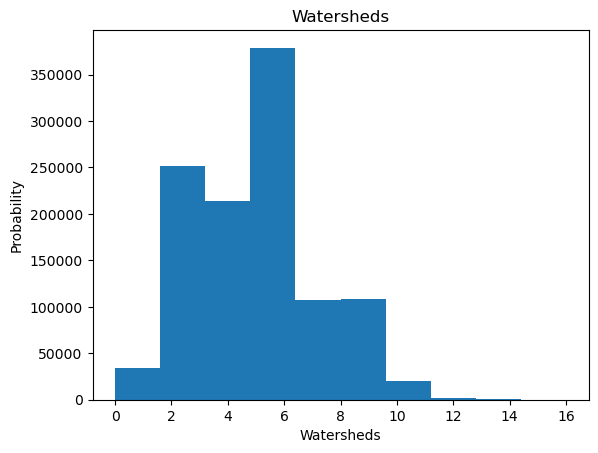

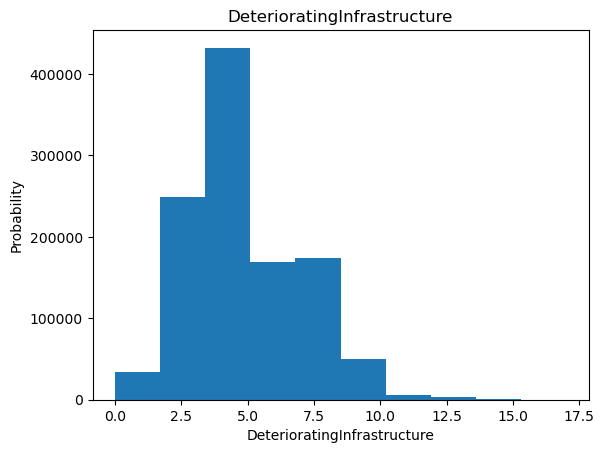

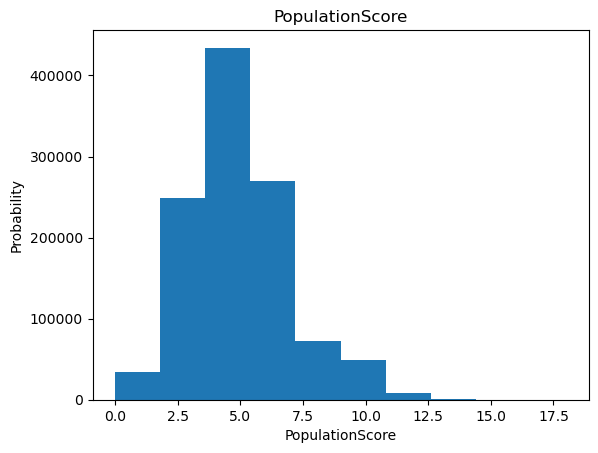

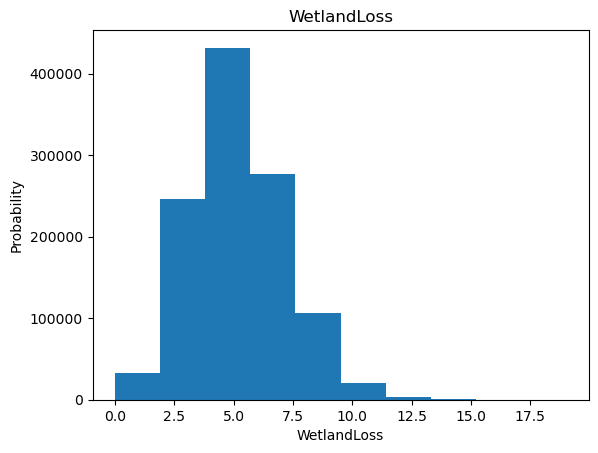

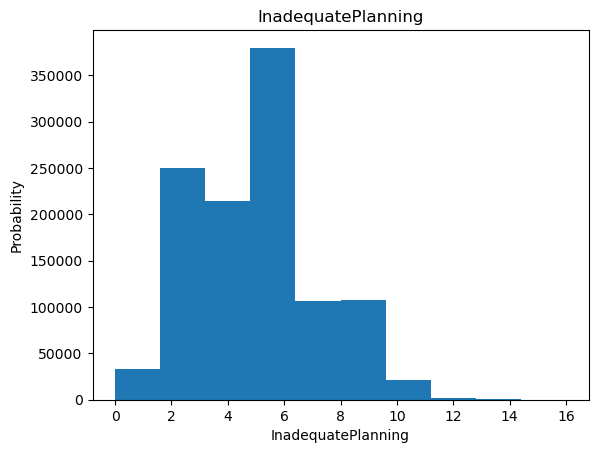

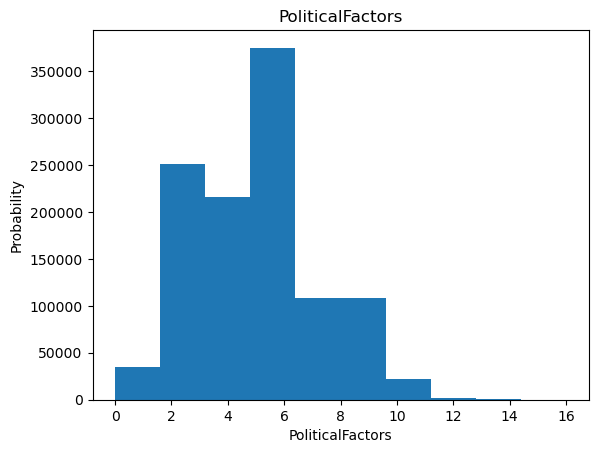

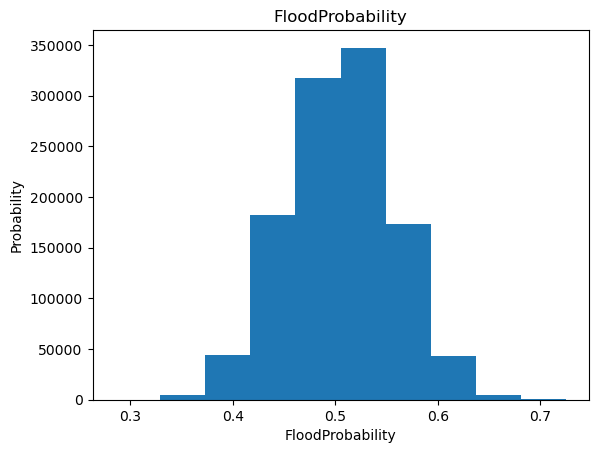

In [39]:
for column in train.columns:
    plt.hist(train[column])
    plt.title(column)
    plt.ylabel("Probability")
    plt.xlabel(column)
    plt.show()

In [40]:
X = train.drop(['FloodProbability'], axis=1).values
y = train['FloodProbability'].values

X_test = test.values

In [41]:
X_train, X_test, y_train, y_test= train_test_split(X,y,test_size= 0.2, random_state= 42)
X_val = X_test


In [42]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train,y_train)


LinearRegression()

In [43]:
y_pred = model.predict(X_val)
y_pred

array([0.53392548, 0.58491114, 0.52256976, ..., 0.53390792, 0.49426442,
       0.50589005])

In [44]:
model.score(X_test,y_test)

0.8448773580510154

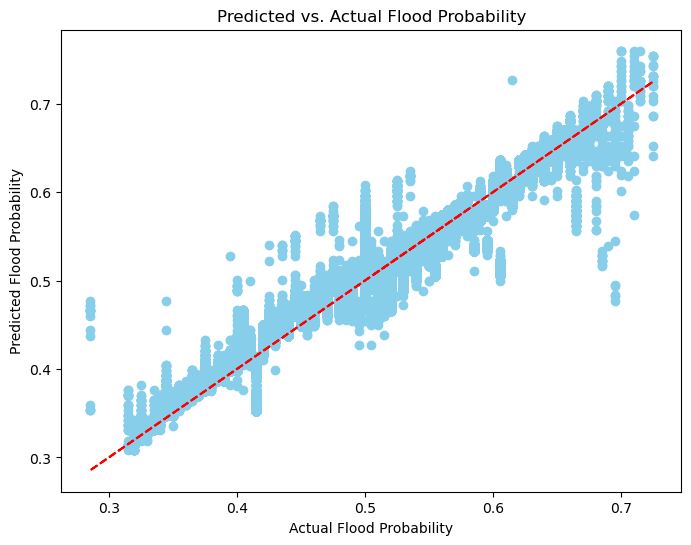

In [45]:
# Scatter Plot of Predicted vs. Actual Sale Prices
plt.figure(figsize=(8, 6))
plt.scatter(y_train, model.predict(X_train), color='skyblue')
plt.plot(y_train, y_train, color='red', linestyle='--')
plt.title('Predicted vs. Actual Flood Probability')
plt.xlabel('Actual Flood Probability')
plt.ylabel('Predicted Flood Probability')
plt.show()

In [46]:
submission = pd.DataFrame()

submission['id'] = X_val[:,0]
submission['FloodProbability'] = y_pred

submission.to_csv('submission.csv', index=False)

### Conclusion
In this project, we predicted flood probability using environmental data with a linear regression model, achieving an R² score of 0.845. This indicates a strong relationship between the features and flood probability. Further improvements can be made by exploring more complex algorithms or refining the features for better accuracy. Overall, accurate flood predictions are crucial for disaster preparedness and risk management.

In [48]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize and train the model
xgboost_model = xgb.XGBRegressor(random_state=42)
xgboost_model.fit(X_train, y_train)

# Make predictions
y_pred_xgb = xgboost_model.predict(X_val)

# Evaluate the model
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost MAE: {mae_xgb}")
print(f"XGBoost MSE: {mse_xgb}")
print(f"XGBoost R²: {r2_xgb}")


XGBoost MAE: 0.017613571099852995
XGBoost MSE: 0.0004976185148410598
XGBoost R²: 0.8085549393090847
